<a href="https://colab.research.google.com/github/Yonosuke1/data-mining-colab/blob/main/CC19_Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports and Loading**

In [3]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Model selection & preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Save model
import joblib

In [4]:
# Load dataset
url = "https://github.com/janberryjam/ccs8-githubrepositoryactivity/raw/refs/heads/main/XGirls_CleanData.xlsx"
df = pd.read_excel(url)

# Check first rows
df.head()

,Course,Schedule,Previous_Qualification_Grade,Admission_Grade,Displaced_Status,Scholarship_Holder_Status,Financial_Risk,Age,PC1_1st_Sem,PC2_1st_Sem,PC1_2nd_Sem,PC2_2nd_Sem,Performance_Change,Target
0,1,1,-0.804841,0.022229,1,0,1,0,-3.784635,0.682756,-3.918683,0.216433,-0.134048,0
1,9,1,2.076819,1.071926,1,0,2,0,-0.004781,-0.801936,0.127368,-0.774739,0.132149,2
2,4,1,-0.804841,-0.150419,1,0,2,0,-2.561306,0.929043,-2.557660,0.642023,0.003646,0
3,13,1,-0.804841,-0.509526,1,0,1,0,0.165394,-0.652383,0.296103,-0.410020,0.130708,2
4,2,0,-2.473171,1.002867,0,0,1,2,0.034917,-0.407856,0.076946,-0.716695,0.042029,2


# **STEP 1: Model Selection**

Task
* Classification

Evaluation Metrics
* Accuracy
* Precision
* Recall
* F1-score

Simple Model
* Decision Tree
* Logistic Regression

Complex Model
* Random Forest

In [5]:
# Check target variable
df['Target'].value_counts()

,count
Target,
2,2209
0,1421
1,794


In [6]:
df['Target'].unique()

array([0, 2, 1])

Target is already labeled from categorical to numerical encoding.


*   Graduate - 0
*   Enrolled - 1
*   Dropout  - 2



In [7]:
# Check mapping
df[['Target']].drop_duplicates()

,Target
0,0
1,2
16,1


In [9]:
# Define features and target
X = df.drop('Target', axis=1)
y = df['Target']

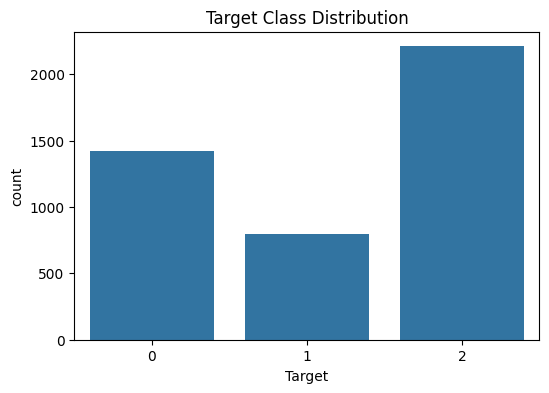

In [10]:
# Distribution of target classes before training and evaluating models
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)
plt.title("Target Class Distribution")
plt.show()

In [11]:
from sklearn.decomposition import PCA

# Reduce features to 2D
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_test)

# Class labels
class_labels = ['Graduate', 'Enrolled', 'Dropout']
colors = ['blue', 'green', 'orange']

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Function to plot with labels
def plot_scatter(ax, labels, title):
    for i, label in enumerate(class_labels):
        mask = labels == i
        ax.scatter(
            X_vis[mask, 0],
            X_vis[mask, 1],
            c=colors[i],
            label=label,
            alpha=0.7
        )
    ax.set_title(title)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.legend()
    ax.grid(True)

# Actual dataset
plot_scatter(axes[0,0], y_test.values, "Actual Dataset Classes")

# Logistic Regression
plot_scatter(axes[0,1], y_pred_lr, "Logistic Regression Predictions")

# Decision Tree
plot_scatter(axes[1,0], y_pred_dt, "Decision Tree Predictions")

# Random Forest
plot_scatter(axes[1,1], y_pred_rf, "Random Forest Predictions")

plt.tight_layout()
plt.show()

NameError: name 'X_test' is not defined

# **STEP 2: Model Training**

**Train-Test Split**

In [12]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set contains {X_train.shape[0]} instances and {X_train.shape[1]} features.")
print(f"Test set contains {X_test.shape[0]} instances and {X_test.shape[1]} features.")

Training set contains 3539 instances and 13 features.
Test set contains 885 instances and 13 features.


### **Train Model**

**Decision Tree**

In [13]:
# Baseline model (Decision Tree)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6474576271186441

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.68      0.69       284
           1       0.28      0.30      0.29       159
           2       0.76      0.75      0.76       442

    accuracy                           0.65       885
   macro avg       0.58      0.58      0.58       885
weighted avg       0.65      0.65      0.65       885



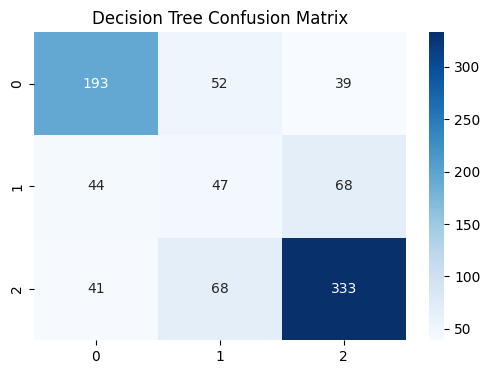

In [14]:
# Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()

**Logistic Regression**

In [15]:
# Baseline comparison (Logistic Regression)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6949152542372882

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73       284
           1       0.30      0.02      0.04       159
           2       0.69      0.90      0.79       442

    accuracy                           0.69       885
   macro avg       0.57      0.56      0.52       885
weighted avg       0.63      0.69      0.63       885



**Random Forest**

In [16]:
# Complex Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7389830508474576

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.75      0.76       284
           1       0.45      0.33      0.38       159
           2       0.79      0.88      0.83       442

    accuracy                           0.74       885
   macro avg       0.67      0.65      0.66       885
weighted avg       0.72      0.74      0.73       885



In [17]:
# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [18]:
# Train best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Train Accuracy:", best_rf.score(X_train, y_train))
print("Test Accuracy:", best_rf.score(X_test, y_test))

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))

Train Accuracy: 0.8838654987284543
Test Accuracy: 0.7502824858757062
Tuned Random Forest Accuracy: 0.7502824858757062


# **STEP 3: Model Evaluation**

**Test Set**

Train Accuracy: 1.0
Test Accuracy: 0.7389830508474576
Untuned Random Forest Accuracy: 0.7389830508474576

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       284
           1       0.45      0.33      0.38       159
           2       0.79      0.88      0.83       442

    accuracy                           0.74       885
   macro avg       0.67      0.65      0.66       885
weighted avg       0.72      0.74      0.73       885



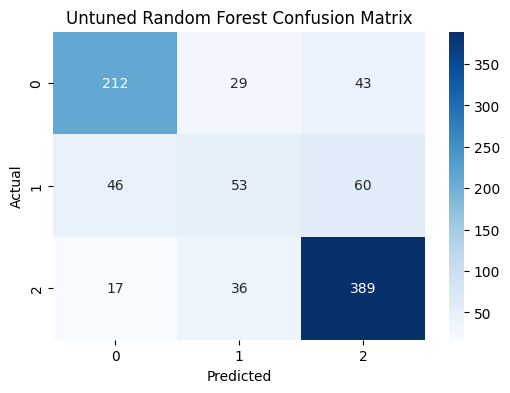

In [19]:
"""**Untuned Random Forest - Test Set**"""

# Retrain untuned Random Forest
rf_model_untuned = RandomForestClassifier(random_state=42)
rf_model_untuned.fit(X_train, y_train)

# Evaluate on test set
y_pred_rf_untuned = rf_model_untuned.predict(X_test)

print("Train Accuracy:", rf_model_untuned.score(X_train, y_train))
print("Test Accuracy:", rf_model_untuned.score(X_test, y_test))
print("Untuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_untuned))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_untuned))

# Confusion matrix
cm_untuned = confusion_matrix(y_test, y_pred_rf_untuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_untuned, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Untuned Random Forest Confusion Matrix")
plt.show()

In [20]:
# Evaluate on test set
y_pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7502824858757062

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.75      0.77       284
           1       0.51      0.37      0.43       159
           2       0.79      0.89      0.83       442

    accuracy                           0.75       885
   macro avg       0.69      0.67      0.68       885
weighted avg       0.74      0.75      0.74       885



In [21]:
# Confusion matrix
y_pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7502824858757062

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.75      0.77       284
           1       0.51      0.37      0.43       159
           2       0.79      0.89      0.83       442

    accuracy                           0.75       885
   macro avg       0.69      0.67      0.68       885
weighted avg       0.74      0.75      0.74       885



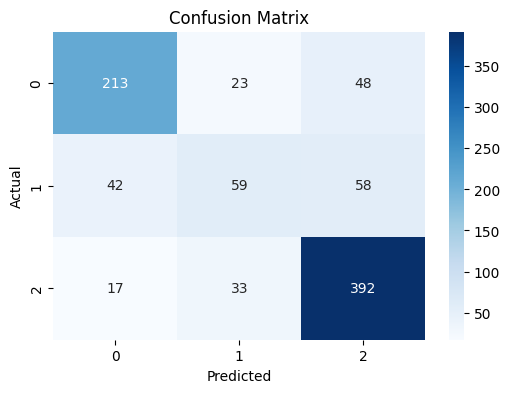

In [22]:
# Confusion matrix interpretation
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Cross-Validation**

In [23]:
# Cross validation
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation Scores: [0.75706215 0.74915254 0.77627119 0.74576271 0.75113122]
Mean CV Accuracy: 0.7558759618580156
Standard Deviation: 0.010838514424979085


# **STEP 4: Model Improvement**

In [28]:
# Improvement 1: Handle class imbalance

#Before Improvement
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

#After Improvement
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Original Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("----------------------------------------------------------------")
print("Improved Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Original Random Forest Accuracy: 0.752542372881356

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.76      0.77       284
           1       0.51      0.36      0.43       159
           2       0.79      0.89      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.67      0.68       885
weighted avg       0.74      0.75      0.74       885

----------------------------------------------------------------
Improved Random Forest Accuracy: 0.752542372881356

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.76      0.77       284
           1       0.51      0.36      0.43       159
           2       0.79      0.89      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.67      0.68       885
weighted avg       0.74      0.75      0.74       885



# **STEP 5: Model Interpretation and Reporting**

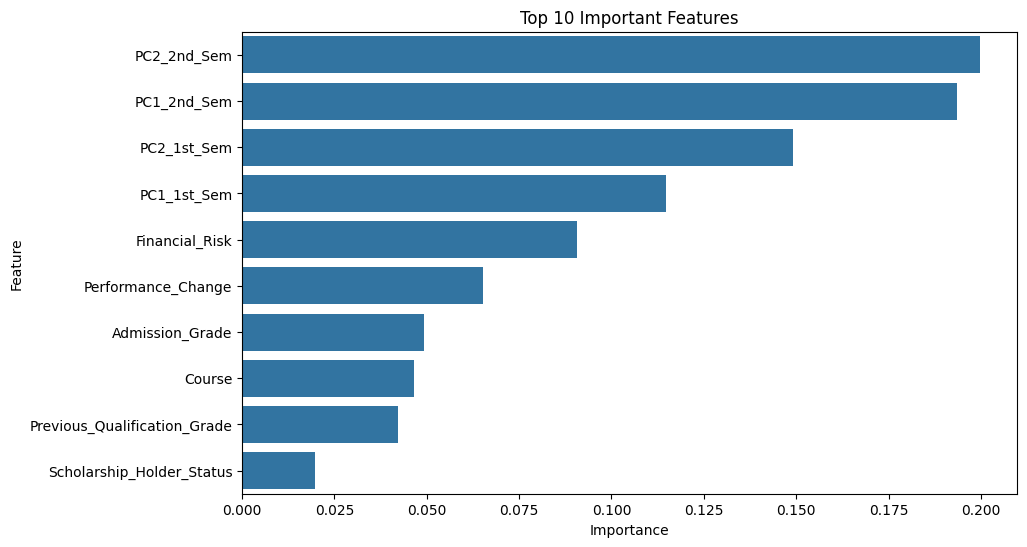

In [27]:
# Feature importance
importances = best_rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

# **Saving the Model**

In [26]:
# Saving model
joblib.dump(best_rf, 'student_dropout_model.pkl')

['student_dropout_model.pkl']

In [25]:
# Download (Delete the hashtag of the following code if you want to download)

#from google.colab import files
#files.download('student_dropout_model.pkl')

In [24]:
print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Class distribution:")
print(df['Target'].value_counts(normalize=True))

Train size: 3539
Test size: 885
Class distribution:
Target
2    0.499322
0    0.321203
1    0.179476
Name: proportion, dtype: float64
